In [3]:
"""QUESTION 1"""
import pandas as pd
import numpy as np
np.random.seed(42)

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

train = pd.read_csv("adult.data", names=columns, na_values=" ?", skipinitialspace=True)
test = pd.read_csv("adult.test", names=columns, na_values=" ?", skipinitialspace=True, skiprows=1)

# The periods at the end were really bothering me.
test["income"] = test["income"].str.replace(".", "", regex=False)

train = train.dropna()
test = test.dropna()

train["income"] = train["income"].apply(lambda x: 1 if x == ">50K" else 0)
test["income"] = test["income"].apply(lambda x: 1 if x == ">50K" else 0)

train.head(5)
test.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0


In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X_train = train.drop(["income"], axis=1)
y_train = train["income"]

X_test = test.drop(["income"], axis=1)
y_test = test["income"]

categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols),
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [5]:
"""QUESTION 1A"""
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [8]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

y_train_prob = clf.predict_proba(X_train)[:, 1]
y_test_prob = clf.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Error": 1 - accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

train_metrics = evaluate(y_train, y_train_pred, y_train_prob)
test_metrics = evaluate(y_test, y_test_pred, y_test_prob)

df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
df = df.astype(float).round(4)
print(df)

       Accuracy   Error  Precision  Recall      F1     AUC
Train    1.0000  0.0000     1.0000  0.9999  0.9999  1.0000
Test     0.8143  0.1857     0.6049  0.6162  0.6105  0.7459


In [13]:
"""QUESTION 1B"""

clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [14]:
y_train_pred = clf_gini.predict(X_train)
y_test_pred = clf_gini.predict(X_test)

y_train_prob = clf_gini.predict_proba(X_train)[:, 1]
y_test_prob = clf_gini.predict_proba(X_test)[:, 1]

In [15]:
train_metrics = evaluate(y_train, y_train_pred, y_train_prob)
test_metrics = evaluate(y_test, y_test_pred, y_test_prob)

df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"]).astype(float).round(4)
print(df)

       Accuracy   Error  Precision  Recall      F1     AUC
Train    1.0000  0.0000     1.0000  0.9999  0.9999  1.0000
Test     0.8116  0.1884     0.5977  0.6186  0.6080  0.7449


In [19]:
"""QUESTION 1C"""
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

def get_results(model, X_tr, y_tr, X_val, y_val):
    model.fit(X_tr, y_tr)

    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    num_nodes = model.tree_.node_count

    return train_acc, val_acc, num_nodes

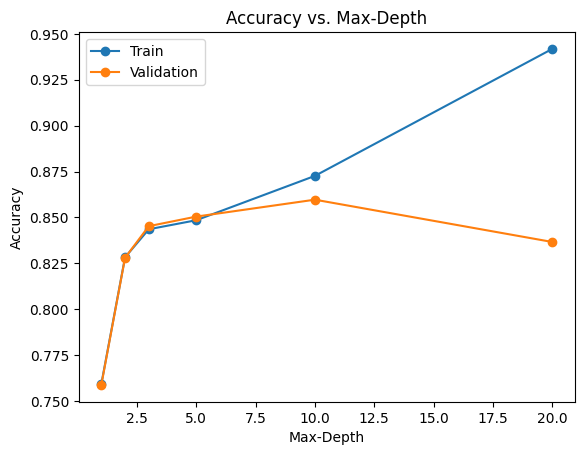

   depth  train_acc  val_acc  nodes
0      1     0.7593   0.7588      3
1      2     0.8283   0.8280      7
2      3     0.8436   0.8452     15
3      5     0.8485   0.8505     55
4     10     0.8726   0.8597    555
5     20     0.9418   0.8366   4101


In [24]:
"""MAX-DEPTH"""
import matplotlib.pyplot as plt

depths = [1, 2, 3, 5, 10, 20]

train_accs = []
val_accs = []
nodes = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    tr_acc, val_acc, n = get_results(clf, X_tr, y_tr, X_val, y_val)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)
    nodes.append(n)

plt.plot(depths, train_accs, marker="o", label="Train")
plt.plot(depths, val_accs, marker="o", label="Validation")

plt.xlabel("Max-Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Max-Depth")
plt.legend()
plt.show()

df_depth = pd.DataFrame({
    "depth": depths,
    "train_acc": train_accs,
    "val_acc": val_accs,
    "nodes": nodes})
print(df_depth.round(4))

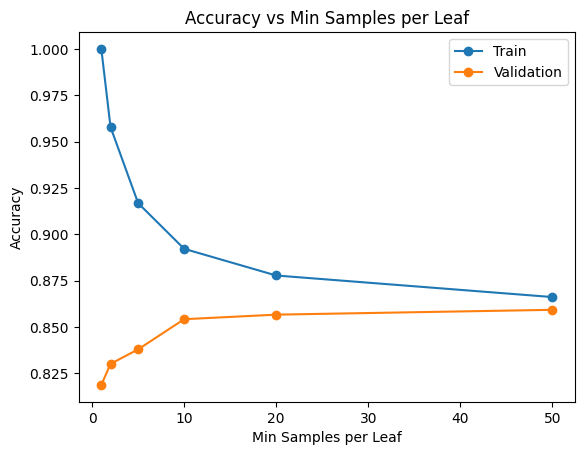

   Leaf Size  Train Acc  Val Acc  Nodes
0          1     1.0000   0.8187   7463
1          2     0.9578   0.8300   6157
2          5     0.9168   0.8379   3633
3         10     0.8921   0.8541   2203
4         20     0.8777   0.8566   1259
5         50     0.8661   0.8592    589


In [25]:
leaf_sizes = [1, 2, 5, 10, 20, 50]

train_accs = []
val_accs = []
nodes = []

for leaf in leaf_sizes:
    clf = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    tr_acc, val_acc, n = get_results(clf, X_tr, y_tr, X_val, y_val)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)
    nodes.append(n)

plt.plot(leaf_sizes, train_accs, marker='o', label="Train")
plt.plot(leaf_sizes, val_accs, marker='o', label="Validation")

plt.xlabel("Min Samples per Leaf")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Min Samples per Leaf")
plt.legend()
plt.show()

df_depth = pd.DataFrame({
    "Leaf Size": leaf_sizes,
    "Train Acc": train_accs,
    "Val Acc": val_accs,
    "Nodes": nodes
})

print(df_depth.round(4))

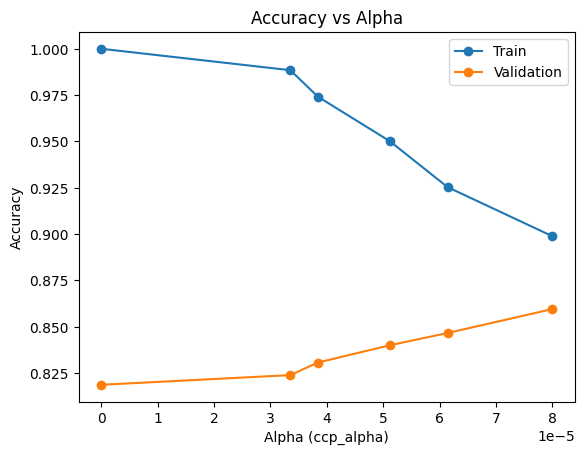

      Alpha  Train Acc   Val Acc  Nodes
0  0.000000   1.000000  0.818670   7463
1  0.000034   0.988444  0.823891   6075
2  0.000038   0.974201  0.830646   4709
3  0.000051   0.950092  0.840012   3149
4  0.000061   0.925330  0.846614   1949
5  0.000080   0.898879  0.859512    845


In [27]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_tr, y_tr)
alphas = path.ccp_alphas
alphas = alphas[::max(1, len(alphas) // 6)]

train_accs = []
val_accs = []
nodes = []

for a in alphas:
    clf = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    tr_acc, val_acc, n = get_results(clf, X_tr, y_tr, X_val, y_val)

    train_accs.append(tr_acc)
    val_accs.append(val_acc)
    nodes.append(n)

plt.plot(alphas, train_accs, marker='o', label="Train")
plt.plot(alphas, val_accs, marker='o', label="Validation")

plt.xlabel("Alpha (ccp_alpha)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Alpha")
plt.legend()
plt.show()

df_depth = pd.DataFrame({
    "Alpha": alphas,
    "Train Acc": train_accs,
    "Val Acc": val_accs,
    "Nodes": nodes
})

print(df_depth.round(10))

In [32]:
"""QUESTION 2A"""
from sklearn.ensemble import RandomForestClassifier

trees = [10, 50, 100, 500]
results = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    y_train_prob = rf.predict_proba(X_train)[:, 1]
    y_test_prob = rf.predict_proba(X_test)[:, 1]

    train_metrics = evaluate(y_train, y_train_pred, y_train_prob)
    test_metrics = evaluate(y_test, y_test_pred, y_test_prob)

    df = pd.DataFrame({
        "Train": {k: float(v) for k, v in train_metrics.items()},
        "Test": {k: float(v) for k, v in test_metrics.items()}
    }).round(4)

    print(f"\n=== T = {t} ===")
    print(df)


=== T = 10 ===
            Train    Test
Accuracy   0.9868  0.8479
Error      0.0132  0.1521
Precision  0.9941  0.7186
Recall     0.9509  0.5855
F1         0.9720  0.6453
AUC        0.9994  0.8746

=== T = 50 ===
            Train    Test
Accuracy   0.9998  0.8511
Error      0.0002  0.1489
Precision  0.9999  0.7183
Recall     0.9991  0.6079
F1         0.9995  0.6585
AUC        1.0000  0.8972

=== T = 100 ===
            Train    Test
Accuracy   1.0000  0.8518
Error      0.0000  0.1482
Precision  0.9999  0.7204
Recall     1.0000  0.6089
F1         0.9999  0.6600
AUC        1.0000  0.9005

=== T = 500 ===
            Train    Test
Accuracy   1.0000  0.8528
Error      0.0000  0.1472
Precision  1.0000  0.7197
Recall     0.9999  0.6175
F1         0.9999  0.6647
AUC        1.0000  0.9024


In [ ]:
"""QUESTION 2C"""
